<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/pull_test/notebooks/day_3_data_visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Environment Setup
#Confirm Python version >= 3.10
import sys
print(f'Python version: {sys.version}')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# 2. Library Imports
import pandas as pd             # Data handling
import numpy as np              # Numerical operations (NaNs, Arrays)
import matplotlib.pyplot as plt # Visualisation

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# 3. Data Retrieval
# 3.1 Load Dataset
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print("Dataset successfully loaded!")
except FileNotFoundError:
    raise FileNotFoundError(f"File not found at path: {FILE_PATH}")

Dataset successfully loaded!


In [ ]:
# 3.2 Check Structure
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


In [ ]:
# 4. Data Cleaning
# 4.1 Create Working Copy
df_clean = df.copy()

In [ ]:
# 4.2 Gender Cleaning
gender_map = {'Male': 1, 'MALE': 1, '1': 1,
              'Female': 0, 'FEMALE': 0, '0': 0}
df_clean['Gender'] = df_clean['Gender'].map(gender_map)

In [ ]:
# 4.3 Numeric Cleaning Function
def clean_numeric(column, min_val=None, max_val=None):
    """
    Cleans a numeric column by coercing invalid values and handling outliers.

    Args:
        column (str): Column name in df_clean to clean.
        min_val (float, optional): Minimum valid threshold.
        max_val (float, optional): Maximum valid threshold.

    Returns:
        pandas.Series: Cleaned numeric column with NaNs replaced by median.
    """

    col = pd.to_numeric(df_clean[column], errors='coerce')
    if min_val is not None:
        col.loc[col < min_val] = np.nan
    if max_val is not None:
        col.loc[col > max_val] = np.nan
    return col.fillna(col.median())

In [ ]:
# 4.4 Apply Cleaning to Clinical Variables
df_clean['GCS'] = clean_numeric('GCS', 3, 15)
df_clean['SBP'] = clean_numeric('SBP', 50, 250)
df_clean['DBP'] = clean_numeric('DBP', 30, 150)
df_clean['pulse'] = clean_numeric('pulse', 20, 250)
df_clean['RR'] = clean_numeric('RR', 5, 60)

In [ ]:
# 4.5 Temperature Conversion
def to_celsius(val):
    """
    Converts temperature values to Celsius.

    Args:
        val (str or float): Temperature value (C, F, or numeric).

    Returns:
        float: Temperature in Celsius, or NaN if invalid.
    """

    if pd.isnull(val):
        return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'):
            return float(s[:-1])
        elif s.endswith('F'):
            return (float(s[:-1]) - 32) * 5/9
        else:
            return float(s)
    except:
        return np.nan

df_clean['Temp'] = df_clean['Temp'].apply(to_celsius)
df_clean['Temp'] = clean_numeric('Temp', 32, 43)

In [ ]:
# 4.6 Oxygen and MAP Handling
#FiO2 (Oxygen)
df_clean['Fio2'] = pd.to_numeric(df_clean['Fio2'], errors='coerce')
df_clean['Fio2'] = df_clean['Fio2'].fillna(df_clean['Fio2'].median())

#MAP Calculation
df_clean['MAP'] = pd.to_numeric(df_clean['MAP'], errors='coerce')
df_clean['MAP_calc'] = (df_clean['SBP'] + 2 * df_clean['DBP']) / 3
df_clean['MAP'] = df_clean['MAP'].fillna(df_clean['MAP_calc'])
df_clean.drop(columns=['MAP_calc'], inplace=True)

In [ ]:
#4.7 Validation Check
print(f"Clean dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print(f"Remaining NaNs: {df_clean.isnull().sum().sum()}")

Clean dataset: 2205 rows x 11 columns
Remaining NaNs: 0


In [ ]:
# 5. Data Visualisation
# 5.1 Plot Setup Utilities
"""
Create a standardised figure and axis for all plots. Ensures consistent sizing and readability across visualisations.
"""

def create_figure():
    """
    Creates a standard matplotlib figure and axis with consistent styling.

    Args:
        None

    Returns:
        tuple: (fig, ax) matplotlib figure and axis objects.
    """

    fig, ax = plt.subplots(figsize=(13, 7), constrained_layout=False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    return fig, ax

# Apply layout formatting, save the figure, and render output. Standardises export quality across all plots
def finalize_plot(filename):
    """
    Saves and displays a matplotlib plot with consistent formatting.

    Args:
        filename (str): Output filename for the saved plot image.

    Returns:
        None
    """

    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")

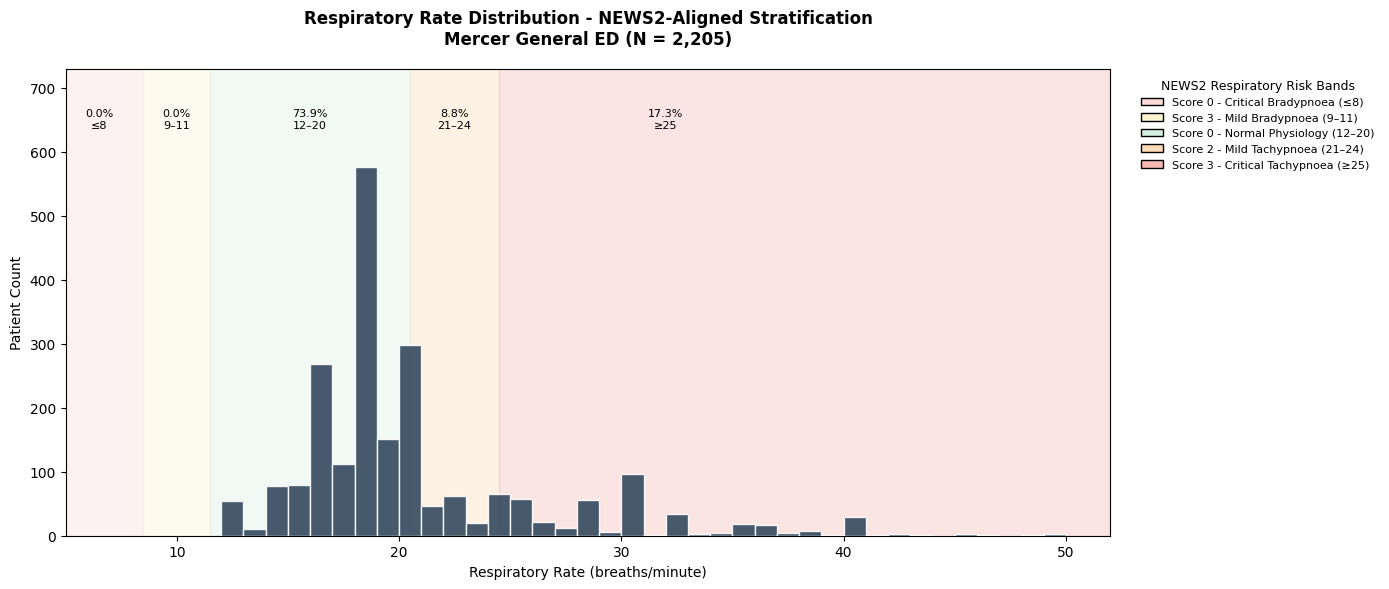

In [ ]:
# 5.2 Respiratory Rate Distribution
def plot_news2_stratified_rr(df_clean):
    """
    Plots respiratory rate distribution with NEWS2-aligned clinical risk bands.

    Args:
        df_clean (pandas.DataFrame): Cleaned dataset containing RR column.

    Returns:
        None: Displays and saves the distribution plot.

    This function:
    - Plots a histogram of respiratory rate (RR)
    - Overlays NEWS2-aligned clinical risk bands
    - Calculates cohort proportions per band
    - Annotates KPI percentages above the distribution
    - Outputs a publication-ready figure
    """

    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(14, 6))
    rr = df_clean['RR']

    # Histogram (distribution core)
    counts, _, _ = ax.hist(
        rr,
        bins=np.arange(rr.min(), rr.max() + 1, 1),
        color='#34495E', edgecolor='white', alpha=0.9, zorder=3
    )

    # Clinical risk band overlays - (xmin, xmax, colour, label)
    bands = [
        (0,    8.5,           '#FADBD8', 'Score 0 - Critical Bradypnoea (≤8)'),
        (8.5,  11.5,          '#FCF3CF', 'Score 3 - Mild Bradypnoea (9–11)'),
        (11.5, 20.5,          '#D4EFDF', 'Score 0 - Normal Physiology (12–20)'),
        (20.5, 24.5,          '#FEDBB7', 'Score 2 - Mild Tachypnoea (21–24)'),
        (24.5, rr.max() + 5,  '#F5B7B1', 'Score 3 - Critical Tachypnoea (≥25)'),
    ]

    for xmin, xmax, colour, _ in bands:
        ax.axvspan(xmin, xmax, color=colour, alpha=0.35)

    # Cohort proportions (NEWS2 bands) + KPI annotation values
    kpi_values = [
        (6.5,  (rr <= 8).mean() * 100,                        '≤8'),
        (10,   ((rr >= 9)  & (rr <= 11)).mean() * 100,        '9–11'),
        (16,   ((rr >= 12) & (rr <= 20)).mean() * 100,        '12–20'),
        (22.5, ((rr >= 21) & (rr <= 24)).mean() * 100,        '21–24'),
        (32,   (rr >= 25).mean() * 100,                       '≥25'),
    ]

    # Position annotations above histogram
    y_top = max(counts) * 1.10

    for x, pct, band_label in kpi_values:
        ax.text(x, y_top, f"{pct:.1f}%\n{band_label}",
                ha='center', va='bottom', fontsize=8, color='black')

    # Title, axis labels, and limits
    ax.set_title(
        'Respiratory Rate Distribution - NEWS2-Aligned Stratification\n'
        'Mercer General ED (N = 2,205)',
        fontsize=12, fontweight='bold', color='black', pad=18
    )
    ax.set_xlabel('Respiratory Rate (breaths/minute)')
    ax.set_ylabel('Patient Count')
    ax.set_xlim(5, rr.max() + 2)
    ax.set_ylim(0, y_top * 1.15) # Lock y-limit so annotations remain visible

    # Legend formatting
    ax.legend(
        handles=[Patch(facecolor=c, edgecolor='black', label=l) for _, _, c, l in bands],
        frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1),
        fontsize=8, title='NEWS2 Respiratory Risk Bands', title_fontsize=9
    )

    # Final layout + export
    plt.tight_layout()
    plt.savefig('news2_rr_distribution.png', dpi=200)
    plt.show()

# Execute plot
plot_news2_stratified_rr(df_clean)

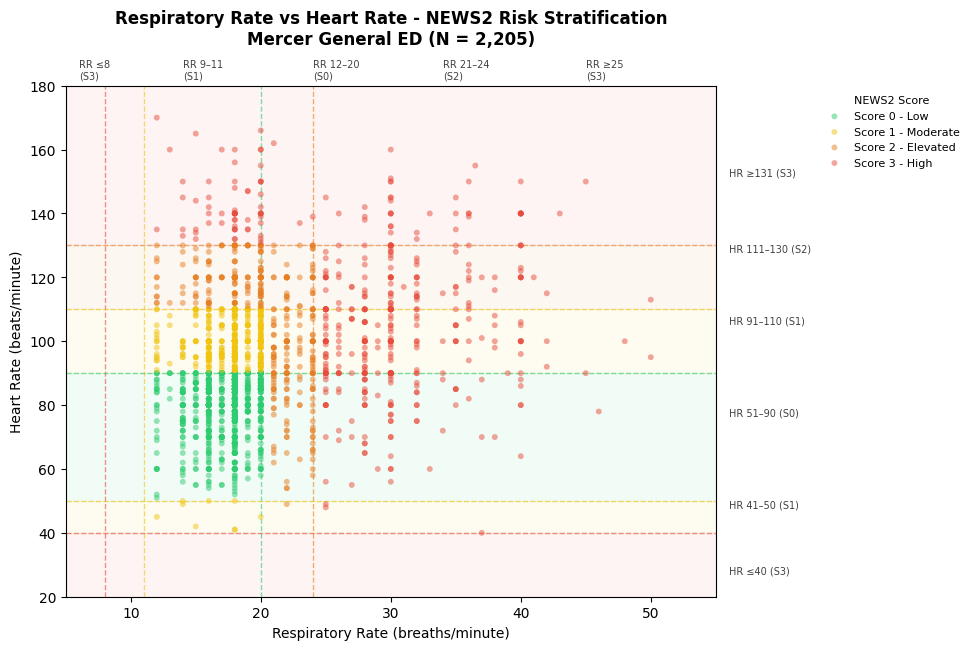

Saved: rr_vs_pulse_clean_clinical.png


In [ ]:
# 5.3 Respiratory Rate vs Heart Rate Distribution
def plot_rr_vs_pulse(df_clean):
  def plot_rr_vs_pulse(df_clean):
    """
    Plots Respiratory Rate vs Heart Rate with NEWS2 risk stratification.

    Args:
        df_clean (pandas.DataFrame): Cleaned dataset containing RR and pulse columns.

    Returns:
        None: Displays and saves the scatter plot.

    This visualisation is a clinical scatter plot based on the National Early Warning Score 2 (NEWS2)
    system, used to assess patient deterioration risk by comparing Respiratory Rate (RR) and Heart Rate (HR).

    It maps individual patient observations onto a two-dimensional physiological space to identify
    patterns of clinical stability and deterioration.

    Axes
    X-axis: Respiratory Rate (breaths per minute), range 5–50
    Y-axis: Heart Rate (beats per minute), range 20–180

    Coloured dashed threshold lines and background shading represent NEWS2 escalation boundaries.

    Risk Stratification
    Green (Score 0 — Low):
        RR 12–20 AND HR 51–90 → stable physiology

    Yellow (Score 1 — Moderate):
        RR 9–11 or 21–24 OR HR 41–50 or 91–110 → early deviation

    Orange (Score 2 — Elevated):
        RR 21–24 OR HR 111–130 → moderate abnormal physiology

    Red (Score 3 — High):
        RR ≤8 or ≥25 OR HR ≤40 or ≥131 → severe abnormal physiology

    Dot colour reflects the highest NEWS2 score across both RR and HR for each observation.
    """

    fig, ax = create_figure()
    ax.grid(False)
    fig.subplots_adjust(top=0.85, right=0.60, left=0.1, bottom=0.12)

    rr, hr = df_clean['RR'], df_clean['pulse']

    # NEWS2 scores
    rr_score = np.select(
        [(rr <= 8) | (rr >= 25), (rr >= 21) & (rr <= 24), (rr >= 9) & (rr <= 11)],
        [3, 2, 1], default=0
    )
    hr_score = np.select(
        [(hr <= 40) | (hr >= 131), (hr >= 111) & (hr <= 130), (hr >= 41) & (hr <= 50) | (hr >= 91) & (hr <= 110)],
        [3, 2, 1], default=0
    )
    df_clean['news2_score'] = np.maximum(rr_score, hr_score)

    score_map = {
        0: ('Score 0 - Low',      '#2ECC71'),
        1: ('Score 1 - Moderate', '#F1C40F'),
        2: ('Score 2 - Elevated', '#E67E22'),
        3: ('Score 3 - High',     '#E74C3C')
    }

    # HR risk zone shading
    for y0, y1, colour in [(20, 40, '#E74C3C'), (40, 50, '#F1C40F'), (50, 90, '#2ECC71'),
                            (90, 110, '#F1C40F'), (110, 130, '#E67E22'), (130, 180, '#E74C3C')]:
        ax.axhspan(y0, y1, color=colour, alpha=0.06, zorder=0)

    # Threshold lines
    for x, c in [(8, '#E74C3C'), (11, '#F1C40F'), (20, '#2ECC71'), (24, '#E67E22')]:
        ax.axvline(x, linestyle='--', linewidth=1.0, alpha=0.6, color=c)
    for y, c in [(40, '#E74C3C'), (50, '#F1C40F'), (90, '#2ECC71'), (110, '#F1C40F'), (130, '#E67E22')]:
        ax.axhline(y, linestyle='--', linewidth=1.0, alpha=0.6, color=c)

    # Scatter
    for score, (label, colour) in score_map.items():
        subset = df_clean[df_clean['news2_score'] == score]
        ax.scatter(subset['RR'], subset['pulse'], label=label, alpha=0.5, s=18, color=colour, edgecolors='none', zorder=2)

    # RR band labels
    for pos, text in [(0.02, "RR ≤8\n(S3)"), (0.18, "RR 9–11\n(S1)"), (0.38, "RR 12–20\n(S0)"),
                      (0.58, "RR 21–24\n(S2)"), (0.80, "RR ≥25\n(S3)")]:
        ax.text(pos, 1.01, text, transform=ax.transAxes, fontsize=7, alpha=0.75, va='bottom', ha='left')

    # HR band labels
    for pos, text in [(0.05, "HR ≤40 (S3)"), (0.18, "HR 41–50 (S1)"), (0.36, "HR 51–90 (S0)"),
                      (0.54, "HR 91–110 (S1)"), (0.68, "HR 111–130 (S2)"), (0.83, "HR ≥131 (S3)")]:
        ax.text(1.02, pos, text, transform=ax.transAxes, fontsize=7, alpha=0.75, ha='left', va='center')

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='NEWS2 Score', loc='upper left',
              bbox_to_anchor=(1.15, 1), ncol=1, frameon=False, fontsize=8, title_fontsize=8)

    ax.set_title(
        'Respiratory Rate vs Heart Rate - NEWS2 Risk Stratification\nMercer General ED (N = 2,205)',
        fontsize=12, fontweight='bold', pad=30
    )
    ax.set_xlabel('Respiratory Rate (breaths/minute)')
    ax.set_ylabel('Heart Rate (beats/minute)')
    ax.set_xlim(5, 55)
    ax.set_ylim(20, 180)

    finalize_plot('rr_vs_pulse_clean_clinical.png')

plot_rr_vs_pulse(df_clean)